In [22]:
import tomotopy as tp
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from operator import itemgetter
import matplotlib.pyplot as plt
import pandas as pd
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
import openai
from googletrans import Translator

In [23]:
top_n = 20

In [24]:
def get_word_embedding_based_similarity(topic1, topic2):
    similarity = 0
    for i in [word[0] for word in hlda_model.get_topic_words(topic1, top_n=top_n)]:
        for j in [word[0] for word in hlda_model.get_topic_words(topic2, top_n=top_n)]:
            similarity+= word2vec_model.wv.similarity(i,j)
    return similarity/(top_n*top_n)

In [25]:
word2vec_model = Word2Vec.load('../models/word2vec.model')

In [26]:
input_data = pd.read_feather('../Datasets/dataset.ftr')
texts =input_data.okt

dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]


In [27]:
def get_similarity(topn_dict):
    similarity = 0
    cnt = 0
    for d1_topic in topn_dict:
        similarity+=get_word_embedding_based_similarity(0,d1_topic)
        cnt+=1
        for d2_topic in topn_dict.get(d1_topic):
            similarity+=get_word_embedding_based_similarity(d1_topic, d2_topic)
            cnt+=1
    s = similarity/cnt
    return s

In [28]:
def get_diveristy(topn_dict):
    cnt = len(topn_dict)
    diversity = 0
    for d1_topic in topn_dict:
        diversity += (1-get_word_embedding_based_similarity(0,d1_topic))
        
        if len(topn_dict.get(d1_topic)) == 1: continue
        else : d1_topic_list = topn_dict.get(d1_topic)
        for i in range(len(d1_topic_list)):
            for j in range(i):
                diversity += (1 - get_word_embedding_based_similarity(d1_topic_list[i],d1_topic_list[j]))
                cnt+=1
    return diversity / cnt

In [ ]:
div_s = 0
child_list = node.childs
for i in range(len(child_list)):
    for j in range(i):
        div_s +=(1-get_similarity(child_list[i],child_list[j],k))
div_s /= sum(range(i))
return div_s

In [30]:
cohs = []
score_list = []
for sample_num in range(5):
    hlda_model = tp.HLDAModel.load(f'../models/hlda_{sample_num}.bin')
    topic_numdoc = {}
    
    # parent-child dictionary
    total =0
    for depth1 in hlda_model.children_topics(0):
        for topic in hlda_model.children_topics(depth1):
            total +=hlda_model.num_docs_of_topic(topic)
            topic_numdoc[topic] = hlda_model.num_docs_of_topic(topic)
            
            
    # get coherence socre       
    coh_list = []
    dicts = []
    for topn in range(10,55,5):
        res = dict(sorted(topic_numdoc.items(), key=itemgetter(1), reverse=True)[:topn])
        topn_dict = {}
        for child in res:
            #print("parents: ",hlda_model.parent_topic(child), " topic : ",child )
            if hlda_model.parent_topic(child) in topn_dict:
                temp = topn_dict.get(hlda_model.parent_topic(child))
                temp.append(child)
                topn_dict[hlda_model.parent_topic(child)] = temp
            else : topn_dict[hlda_model.parent_topic(child)] = [child]  



        topics = []
        topics.append([word[0] for word in hlda_model.get_topic_words(0, top_n=top_n)])
        for d1_topic in topn_dict:
            topics.append([word[0] for word in hlda_model.get_topic_words(d1_topic, top_n=top_n)])
            for d2_topic in topn_dict.get(d1_topic):
                topics.append([word[0] for word in hlda_model.get_topic_words(d2_topic, top_n=top_n)])


        cm = CoherenceModel(topics = topics,
                       #corpus = corpus,
                       dictionary = dictionary,
                       texts = texts,
                       coherence = 'c_npmi')
        coh_list.append(cm.get_coherence())
        cohs.append(cm.get_coherence())
        dicts.append(topn_dict)
        
        
        # get proposed score
        
    similarity=get_similarity(dicts[np.argmax(coh_list)])
    diversity=get_diveristy(dicts[np.argmax(coh_list)])
    coherence =max(coh_list)
    score = (0.3 *(similarity) + 0.3*(diversity)+0.4*(coherence))
    temp = [similarity,diversity,coherence,score]
    score_list.append(temp)

In [31]:
print(((score_list[0][0])+(score_list[1][0])+(score_list[2][0])+(score_list[3][0])+(score_list[4][0]))/5)
print(((score_list[0][1])+(score_list[1][1])+(score_list[2][1])+(score_list[3][1])+(score_list[4][1]))/5)
print(((score_list[0][2])+(score_list[1][2])+(score_list[2][2])+(score_list[3][2])+(score_list[4][2]))/5)
print(((score_list[0][3])+(score_list[1][3])+(score_list[2][3])+(score_list[3][3])+(score_list[4][3]))/5)

0.5646536533167323
0.46398459284549354
-0.04336958492715111
0.2912436398778073


In [32]:
print(((score_list[0][3])+(score_list[1][3])+(score_list[2][3])+(score_list[3][3])+(score_list[4][3]))/5)

0.2912436398778073


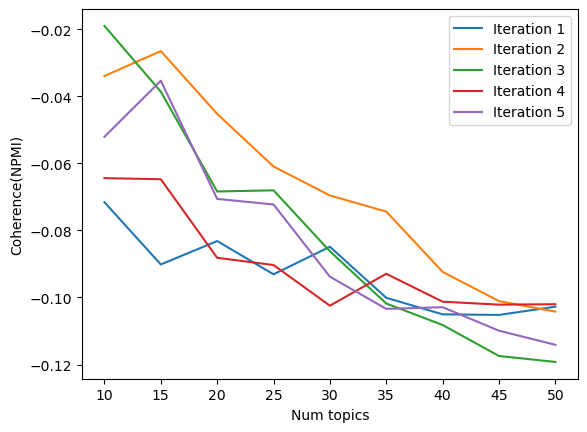

In [48]:
import matplotlib.pyplot as plt
plt.plot(range(10,55,5),cohs[:9], label ='Iteration 1')
plt.plot(range(10,55,5),cohs[9:18], label ='Iteration 2')
plt.plot(range(10,55,5),cohs[18:27],label ='Iteration 3')
plt.plot(range(10,55,5),cohs[27:36], label ='Iteration 4')
plt.plot(range(10,55,5),cohs[36:], label ='Iteration 5')
plt.xticks(range(10,55,5))
plt.xlabel('Num topics')
plt.ylabel('Coherence(NPMI)')
plt.legend()
plt.savefig('../figures/cohrernce_hlda', bbox_inches='tight')

In [14]:
print(((score_list[0][0])+(score_list[1][0])+(score_list[2][0])+(score_list[3][0])+(score_list[4][0]))/5)
print(((score_list[0][1])+(score_list[1][1])+(score_list[2][1])+(score_list[3][1])+(score_list[4][1]))/5)
print(((score_list[0][2])+(score_list[1][2])+(score_list[2][2])+(score_list[3][2])+(score_list[4][2]))/5)
print(((score_list[0][3])+(score_list[1][3])+(score_list[2][3])+(score_list[3][3])+(score_list[4][3]))/5)

0.5646536533167323
0.46398459284549354
-0.04336958492715111
0.2912436398778073


In [15]:
print(((score_list[0][3])+(score_list[1][3])+(score_list[2][3])+(score_list[3][3])+(score_list[4][3]))/5)

0.2912436398778073


# Interpretation

In [37]:
hlda_model = tp.HLDAModel.load(f'../models/hlda_{np.argmax(score_list)}.bin')
topic_numdoc = {}

# parent-child dictionary
total =0
for depth1 in hlda_model.children_topics(0):
    for topic in hlda_model.children_topics(depth1):
        total +=hlda_model.num_docs_of_topic(topic)
        topic_numdoc[topic] = hlda_model.num_docs_of_topic(topic)


# get coherence socre       
coh_list = []
dicts = []
for topn in range(10,50,5):
    res = dict(sorted(topic_numdoc.items(), key=itemgetter(1), reverse=True)[:topn])
    topn_dict = {}
    for child in res:
        #print("parents: ",hlda_model.parent_topic(child), " topic : ",child )
        if hlda_model.parent_topic(child) in topn_dict:
            temp = topn_dict.get(hlda_model.parent_topic(child))
            temp.append(child)
            topn_dict[hlda_model.parent_topic(child)] = temp
        else : topn_dict[hlda_model.parent_topic(child)] = [child]  



    topics = []
    topics.append([word[0] for word in hlda_model.get_topic_words(0, top_n=top_n)])
    for d1_topic in topn_dict:
        topics.append([word[0] for word in hlda_model.get_topic_words(d1_topic, top_n=top_n)])
        for d2_topic in topn_dict.get(d1_topic):
            topics.append([word[0] for word in hlda_model.get_topic_words(d2_topic, top_n=top_n)])


    cm = CoherenceModel(topics = topics,
                   #corpus = corpus,
                   dictionary = dictionary,
                   texts = texts,
                   coherence = 'c_npmi')
    coh_list.append(cm.get_coherence())
    dicts.append(topn_dict)

In [38]:
top_n=15
topn_dict = dicts[np.argmax(coh_list)]

topics = []
print("topic0 : ",[word[0] for word in hlda_model.get_topic_words(0, top_n=top_n)])
for d1_topic in topn_dict:
    print("  topic",d1_topic, ": ",[word[0] for word in hlda_model.get_topic_words(d1_topic, top_n=top_n)])
    for d2_topic in topn_dict.get(d1_topic):
        print("    topic",d2_topic, ": ",[word[0] for word in hlda_model.get_topic_words(d2_topic, top_n=top_n)])
    print()


topic0 :  ['부작용', '많다', '추가', '병원', '아프다', '친구', '걱정', '괜찮다', '무섭다', '완료', '힘들다', '상태', '예약', '문제', '교차']
  topic 8 :  ['근육통', '두통', '타이레놀', '통증', '몸살', '증상', '괜찮다', '심하다', '경과', '미열', '오한', '부작용', '피곤하다', '아침', '새벽']
    topic 16 :  ['아프다', '주사', '뻐근하다', '괜찮다', '아픔', '부위', '차갑다', '멀쩡하다', '증상', '머리', '경과', '근육통', '어깨', '독감', '혈통']
    topic 267 :  ['아프다', '머리', '타이레놀', '어지럽다', '온몸', '덥다', '허리', '생리', '짜증', '관절', '저리다', '괜찮다', '체온계', '은은하다', '별로']
    topic 216 :  ['아프다', '멀쩡하다', '인류', '정신', '주말', '기분', '고고', '연차', '완료', '샤크스', '혈통', '한숨', '기절', '화장실', '눈치']
    topic 213 :  ['아프다', '몸살', '기운', '감기', '혈통', '머리', '아픔', '무겁다', '미열', '반갑다', '괴롭다', '검사', '수가', '해제', '심하다']
    topic 128 :  ['타이레놀', '아프다', '괜찮다', '미리', '멀쩡하다', '힘들다', '진통제', '준비', '두시', '약국', '추천', '효과', '약효', '필수', '조심']

  topic 107 :  ['엄마', '아빠', '예약', '아프다', '동생', '괜찮다', '언니', '가족', '부모님', '관람', '여로', '얘기', '지화', '귀엽다', '점심']
    topic 133 :  ['혈통', '완료', '추가', '예정', '스티커', '부럽다', '직원', '자임', '완성', '호호', '다행', '아쉽다', '카톡